In [ ]:
%pip install kagglehub[pandas-datasets]
%pip install openpyxl #Instalando dependência para abrir .XLSX
%pip install matplotlib

In [1]:

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib as plt
import openpyxl as opn 


c:\Users\Support\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np

Carregando diretamente do Kaggle

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = 'iFood.xlsx'

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fayez7/ifood-marketing-campaigns",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("Primeiros dados:", df.head())

C:\Users\Support\AppData\Local\Temp\ipykernel_18800\314115443.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Primeiros dados:    Index  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0   1001   58138        0         0       58       635         88   
1   1002   46344        1         1       38        11          1   
2   1003   71613        0         0       26       426         49   
3   1004   26646        1         0       26        11          4   
4   1005   58293        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  AcceptedCmp2  \
0              546              172                88  ...             0   
1                6                2                 1  ...             0   
2              127              111                21  ...             0   
3               20               10                 3  ...             0   
4              118               46                27  ...             0   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmpOverall  Complain  \
0             0             0     

In [4]:
#Selecionando algumas colunas para análise
pd.DataFrame(df, columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal']).sort_values(by='MntTotal', ascending=False) 
#Quanto maior a Renda (Income) maior o gasto total(MntTotal)? 

,Index,Income,Age,Customer_Days,MntTotal
1467,2468,87679,32,2496,2491
1159,2160,90638,29,2295,2429
1547,2548,90638,29,2295,2429
967,1968,75759,51,2406,2304
1433,2434,93790,50,2296,2304
...,...,...,...,...,...
149,1150,30523,62,2522,8
1225,2226,1730,49,2201,7
2097,3098,33590,46,2397,6
961,1962,4861,55,2166,5


In [5]:
df[df['MntTotal'] > 1000] # Forma de Localizar/Filtrar um Registro

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education
0,1001,58138,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,63,2822,Single,Graduation
11,1012,63033,0,0,82,194,61,480,225,112,...,0,0,0,0,0,0,61,2385,Divorced,Graduation
14,1015,82800,0,0,23,1006,22,115,59,68,...,0,0,0,1,2,0,74,2741,Single,PHD
17,1018,76995,0,1,91,1012,80,498,0,16,...,0,0,0,0,1,0,71,2617,Married,Master
20,1021,2447,1,0,42,1,1,1725,1,1,...,0,0,0,0,0,0,41,2698,Married,Graduation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2184,3185,82032,0,0,54,332,194,377,149,125,...,0,0,0,0,0,0,72,2244,Widow,PHD
2188,3189,75777,0,0,12,712,26,538,69,13,...,0,0,1,1,2,0,38,2519,Single,Master
2197,3198,44802,0,0,71,853,10,143,13,10,...,0,0,0,0,0,0,50,2836,Single,Master
2200,3201,61223,0,1,46,709,43,182,42,118,...,0,0,0,0,0,0,53,2540,Married,Graduation


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Index                2205 non-null   int64 
 1   Income               2205 non-null   int64 
 2   Kidhome              2205 non-null   int64 
 3   Teenhome             2205 non-null   int64 
 4   Recency              2205 non-null   int64 
 5   MntWines             2205 non-null   int64 
 6   MntFruits            2205 non-null   int64 
 7   MntMeatProducts      2205 non-null   int64 
 8   MntFishProducts      2205 non-null   int64 
 9   MntSweetProducts     2205 non-null   int64 
 10  MntRegularProds      2205 non-null   int64 
 11  MntGoldProds         2205 non-null   int64 
 12  MntTotal             2205 non-null   int64 
 13  NumDealsPurchases    2205 non-null   int64 
 14  NumWebPurchases      2205 non-null   int64 
 15  NumCatalogPurchases  2205 non-null   int64 
 16  NumSto

In [5]:
pd.DataFrame(df, columns=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntRegularProds','MntGoldProds','MntTotal'  ])

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntRegularProds,MntGoldProds,MntTotal
0,635,88,546,172,88,1441,88,1529
1,11,1,6,2,1,15,6,21
2,426,49,127,111,21,692,42,734
3,11,4,20,10,3,43,5,48
4,173,43,118,46,27,392,15,407
...,...,...,...,...,...,...,...,...
2200,709,43,182,42,118,847,247,1094
2201,406,0,30,0,0,428,8,436
2202,908,48,217,32,12,1193,24,1217
2203,428,30,214,80,30,721,61,782


In [20]:
df['MntTotal_>_1k'] = df['MntTotal'] > 1000 # Criando uma coluna que o valor gasto seja maior que 1k

Retornando gastos abaixo de 1k

In [21]:
#Filtrando valores abaixo de 1k
pd.DataFrame(df[df['MntTotal_>_1k'] == False], columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal', 'MntTotal_>_1k']).sort_values(by='MntTotal', ascending=False) 

,Index,Income,Age,Customer_Days,MntTotal,MntTotal_>_1k
1167,2168,62000,68,2467,1000,False
1470,2471,65492,61,2313,998,False
1774,2775,78416,44,2161,996,False
156,1157,66951,32,2398,993,False
1845,2846,69932,56,2541,992,False
...,...,...,...,...,...,...
1835,2836,11448,45,2355,8,False
1225,2226,1730,49,2201,7,False
2097,3098,33590,46,2397,6,False
961,1962,4861,55,2166,5,False


In [6]:
df['Teenhome'].sum() 

np.int64(1117)

In [7]:
#Visualizar com coluna removida
df.drop('Index',axis= 1)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntRegularProds,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education
0,58138,0,0,58,635,88,546,172,88,1441,...,0,0,0,0,0,0,63,2822,Single,Graduation
1,46344,1,1,38,11,1,6,2,1,15,...,0,0,0,0,0,0,66,2272,Single,Graduation
2,71613,0,0,26,426,49,127,111,21,692,...,0,0,0,0,0,0,55,2471,Together,Graduation
3,26646,1,0,26,11,4,20,10,3,43,...,0,0,0,0,0,0,36,2298,Together,Graduation
4,58293,1,0,94,173,43,118,46,27,392,...,0,0,0,0,0,0,39,2320,Married,PHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,118,847,...,0,0,0,0,0,0,53,2540,Married,Graduation
2201,64014,2,1,56,406,0,30,0,0,428,...,0,0,0,0,1,0,74,2178,Together,PHD
2202,56981,0,0,91,908,48,217,32,12,1193,...,0,0,1,0,1,0,39,2314,Divorced,Graduation
2203,69245,0,1,8,428,30,214,80,30,721,...,0,0,0,0,0,0,64,2315,Together,Master


In [8]:
df[df['Age'] < 25]

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education
43,1044,7500,0,0,24,3,18,14,15,22,...,0,0,0,0,0,0,24,2756,Married,2n Cycle
1150,2151,14421,0,0,81,0,0,2,3,3,...,0,1,0,0,1,0,24,2291,Married,Basic


In [9]:
df.iloc[:,18:23] # Seleção de Coluna via 'iloc'

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
...,...,...,...,...,...
2200,0,0,0,0,0
2201,1,0,0,0,0
2202,0,0,0,1,0
2203,0,0,0,0,0


In [12]:
#df.sort_index()
df.sort_index(axis='columns')

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Age,Complain,Customer_Days,Income,...,MntWines,NumCatalogPurchases,NumDealsPurchases,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Recency,Teenhome,education,marital_status
0,0,0,0,0,0,0,63,0,2822,58138,...,635,10,3,4,8,7,58,0,Graduation,Single
1,0,0,0,0,0,0,66,0,2272,46344,...,11,1,2,2,1,5,38,1,Graduation,Single
2,0,0,0,0,0,0,55,0,2471,71613,...,426,2,1,10,8,4,26,0,Graduation,Together
3,0,0,0,0,0,0,36,0,2298,26646,...,11,0,2,4,2,6,26,0,Graduation,Together
4,0,0,0,0,0,0,39,0,2320,58293,...,173,3,5,6,5,5,94,0,PHD,Married
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,0,0,0,0,0,0,53,0,2540,61223,...,709,3,2,4,9,5,46,1,Graduation,Married
2201,1,0,0,0,0,1,74,0,2178,64014,...,406,2,7,5,8,7,56,1,PHD,Together
2202,0,0,0,1,0,1,39,0,2314,56981,...,908,3,1,13,2,6,91,0,Graduation,Divorced
2203,0,0,0,0,0,0,64,0,2315,69245,...,428,5,2,10,6,3,8,1,Master,Together


In [13]:
df.sort_values(['Income', 'Customer_Days'])

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,MntTotal_>_1k
1225,2226,1730,0,0,65,1,1,3,1,1,...,0,0,0,0,0,49,2201,Divorced,Graduation,False
20,1021,2447,1,0,42,1,1,1725,1,1,...,0,0,0,0,0,41,2698,Married,Graduation,True
1499,2500,3502,1,0,56,2,1,1,0,0,...,0,0,0,0,0,47,2601,Single,Graduation,False
1820,2821,4023,1,1,29,5,0,1,1,1,...,0,0,0,0,0,57,2165,Married,PHD,False
1949,2950,4428,0,1,0,16,4,12,2,4,...,0,0,0,0,0,51,2426,Married,Graduation,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,101970,0,0,69,722,27,102,44,72,...,0,1,1,3,0,37,2633,Single,Graduation,False
190,1191,102160,0,0,54,763,29,138,76,176,...,0,1,1,3,0,43,2763,Together,PHD,True
238,1239,102692,0,0,5,168,148,444,32,172,...,0,1,1,4,0,46,2609,Divorced,Graduation,False
628,1629,105471,0,0,36,1009,181,104,202,21,...,0,0,1,2,0,50,2683,Together,Graduation,True


In [14]:
df.iloc[1:4,2:5].sort_values(by= 'Recency',ascending=True)

,Kidhome,Teenhome,Recency
2,0,0,26
3,1,0,26
1,1,1,38


In [11]:
(df.groupby(['education'])[['Income','MntTotal']].mean().round(0)).sort_values(by = 'Income', ascending = False)

,Income,MntTotal
education,,
PHD,55221.0,640.0
Master,52630.0,571.0
Graduation,51984.0,571.0
2n Cycle,47625.0,452.0
Basic,20306.0,59.0


In [18]:
df['MntTotal'].sum()

np.int64(1240896)

In [19]:
#Criando categoria de Idades
bins = [0, 18, 30, 50, 80]
labels = ['0-18', '19-30', '31-50', '51-80']

df['AgeRange'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [20]:
(df['AgeRange'].value_counts() / len(df) * 100).round(1)

AgeRange
31-50    49.2
51-80    48.1
19-30     2.8
0-18      0.0
Name: count, dtype: float64

In [24]:
(df.groupby(['AgeRange'])[['Income','MntTotal']].sum().round(0)).sort_values(by = 'Income', ascending = False)

C:\Users\Support\AppData\Local\Temp\ipykernel_18800\2544551100.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(['AgeRange'])[['Income','MntTotal']].sum().round(0)).sort_values(by = 'Income', ascending = False)


,Income,MntTotal
AgeRange,,
51-80,59185622,669293
31-50,51415600,525766
19-30,3225497,45837
0-18,0,0


<Axes: xlabel='AgeRange'>

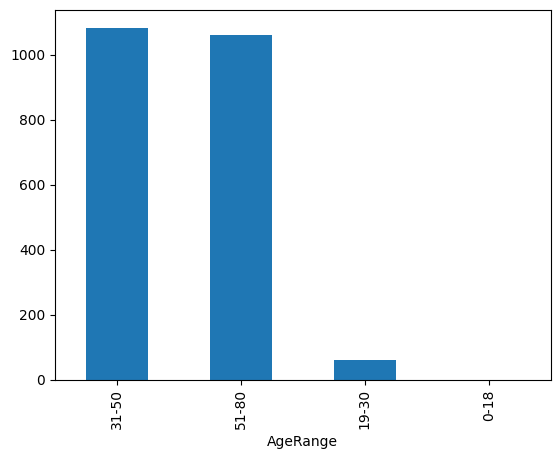

In [21]:
df['AgeRange'].value_counts().plot(kind = 'bar')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Index                2205 non-null   int64   
 1   Income               2205 non-null   int64   
 2   Kidhome              2205 non-null   int64   
 3   Teenhome             2205 non-null   int64   
 4   Recency              2205 non-null   int64   
 5   MntWines             2205 non-null   int64   
 6   MntFruits            2205 non-null   int64   
 7   MntMeatProducts      2205 non-null   int64   
 8   MntFishProducts      2205 non-null   int64   
 9   MntSweetProducts     2205 non-null   int64   
 10  MntRegularProds      2205 non-null   int64   
 11  MntGoldProds         2205 non-null   int64   
 12  MntTotal             2205 non-null   int64   
 13  NumDealsPurchases    2205 non-null   int64   
 14  NumWebPurchases      2205 non-null   int64   
 15  NumCatalogPurchases  

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'MntTotal'}>],
       [<Axes: title={'center': 'Income'}>, <Axes: >]], dtype=object)

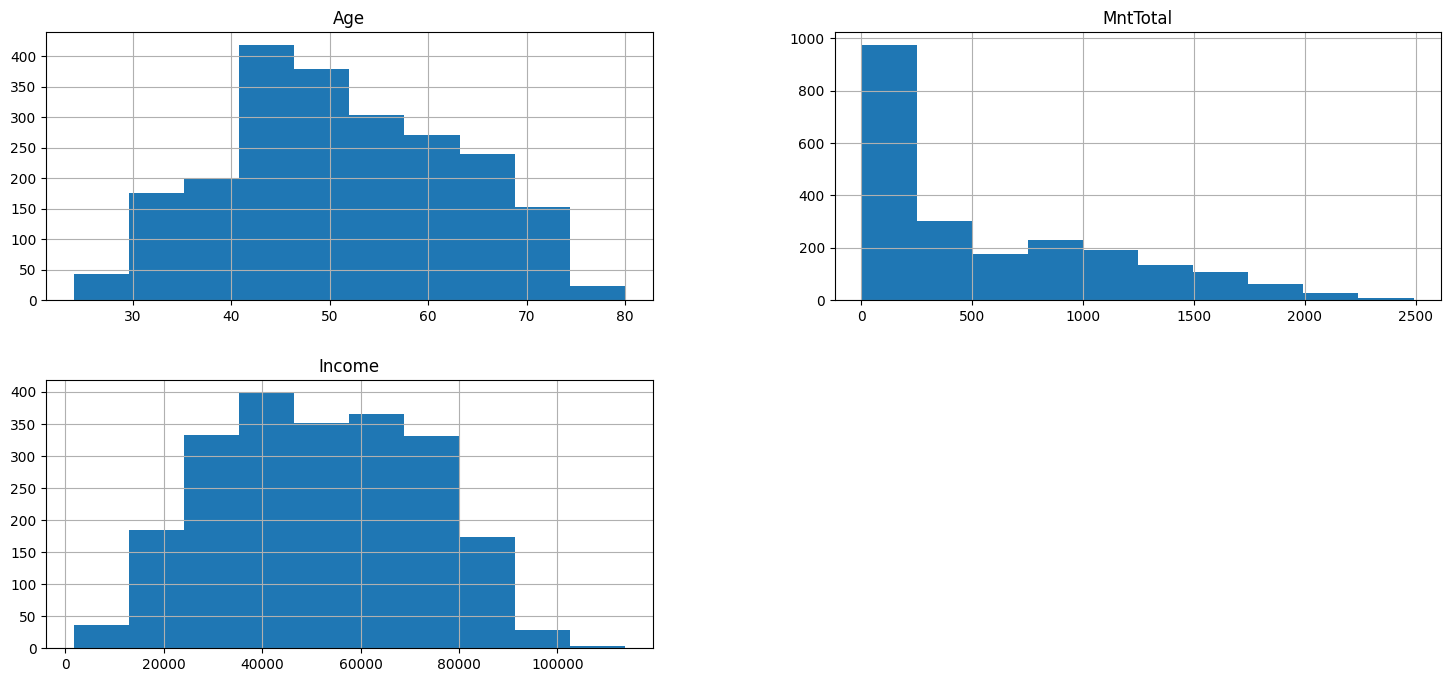

In [28]:
df.hist(column= ['Age', 'MntTotal','Income'], figsize=(18,8))

<Axes: ylabel='marital_status'>

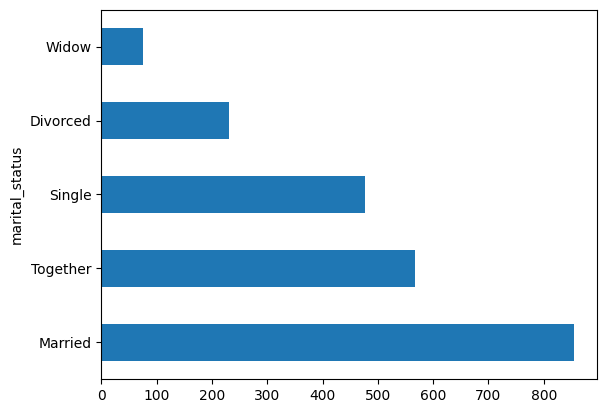

In [43]:
df['marital_status'].value_counts().plot(kind = 'barh')

<Axes: xlabel='education'>

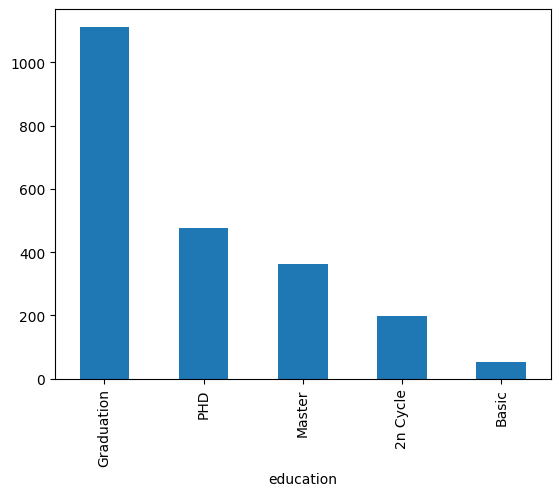

In [40]:
df['education'].value_counts().plot(kind = 'bar')

<Axes: >

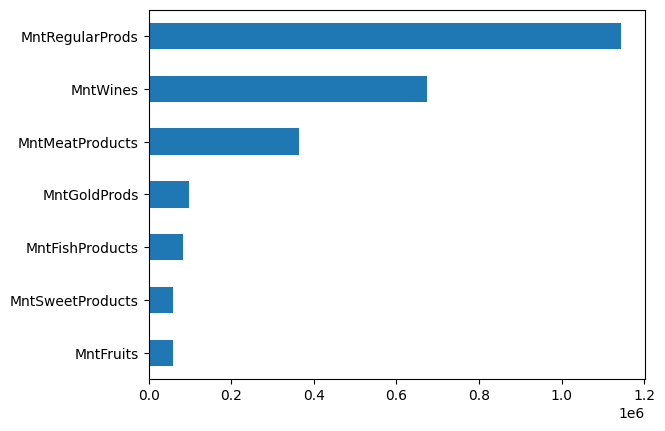

In [50]:
df.iloc[:,5:12].sum().sort_values().plot(kind = 'barh')